## 📌 Problem Statement:

To build a machine learning classification model that predicts hiring decisions and evaluates fairness to reduce bias in AI-based recruitment systems.

## Objective:

To explore the relationship between candidate qualifications, demographic features, and hiring success, building a fair AI model that supports unbiased recruitment

- **Candidate**: A unique identifier for each applicant (Candidate ID).  
- **Gender**: The candidate's self-identified gender (Male, Female, Other).  
- **Age**: The candidate's age in years.  
- **Education**: The highest level of education attained (e.g., Bachelors, Masters, PhD).  
- **Experience Years**: Total years of professional experience.  
- **Skill Score**: A score representing general skill level.  
- **Aptitude**: A score measuring the candidate's natural ability or aptitude.  
- **Technical**: A score reflecting technical knowledge or skills.  
- **Communica**: A score for communication skills.  
- **Certifica**: Number of relevant professional certifications held.  
- **Comp Interview Score**: Score assigned during the company interview process.  
- **Location**: The geographic location of the candidate (Urban, Semi-Urban, Rural).  
- **Job Role Applied**: The specific job position the candidate applied for (e.g., Data Analyst, ML Engineer, HR Executive).  
- **Expected Salary**: The salary amount the candidate is requesting.  
- **Hiring Decision**: The final outcome of the application (1 = Hired, 0 = Not Hired).  


### DATA

https://www.kaggle.com/datasets/roiiith/ai-fair-recrutment-dataset/data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


## import data

In [3]:
df=pd.read_csv("fair_recrutment_dataset final.csv")
df

,Candidate_ID,Gender,Age,Education_Level,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Location,Job_Role_Applied,Expected_Salary,Hiring_Decision
0,1,Male,50,Bachelors,19,48,75,70,65,2.0,5,92,Urban,HR Executive,22214,1
1,2,Other,36,Bachelors,18,9,53,46,25,2.0,4,77,Semi-Urban,Data Analyst,130094,0
2,3,Female,58,Masters,11,1,85,62,72,1.0,3,90,Urban,ML Engineer,78652,0
3,4,Male,48,Masters,0,74,35,79,67,6.0,3,9,Urban,HR Executive,144618,0
4,5,Male,37,Bachelors,0,64,99,25,38,7.0,5,24,Urban,Data Analyst,133865,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121195,47344,Male,37,Bachelors,17,71,55,56,80,8.0,2,70,Urban,Data Analyst,44867,1
121196,111198,Male,49,Masters,14,84,60,99,9,9.0,1,64,Urban,Software Engineer,103035,1
121197,52991,Female,37,Diploma,12,49,59,64,26,8.0,5,89,Urban,Manager,99111,1
121198,101228,Male,41,Bachelors,18,29,15,78,29,3.0,7,22,Semi-Urban,ML Engineer,51287,0


### Understand the Data

In [4]:
df.shape

(121200, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121200 entries, 0 to 121199
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Candidate_ID          121200 non-null  int64  
 1   Gender                121190 non-null  object 
 2   Age                   121200 non-null  int64  
 3   Education_Level       121190 non-null  object 
 4   Experience_Years      121200 non-null  int64  
 5   Skill_Score           121200 non-null  int64  
 6   Aptitude_Test_Score   121200 non-null  int64  
 7   Technical_Test_Score  121200 non-null  int64  
 8   Communication_Score   121200 non-null  int64  
 9   Certifications_Count  121190 non-null  float64
 10  Previous_Companies    121200 non-null  int64  
 11  Interview_Score       121200 non-null  int64  
 12  Location              121200 non-null  object 
 13  Job_Role_Applied      121200 non-null  object 
 14  Expected_Salary       121200 non-null  int64  
 15  

In [6]:
df.describe()

,Candidate_ID,Age,Experience_Years,Skill_Score,Aptitude_Test_Score,Technical_Test_Score,Communication_Score,Certifications_Count,Previous_Companies,Interview_Score,Expected_Salary,Hiring_Decision
count,121200.000000,121200.000000,121200.000000,121200.000000,121200.000000,121200.000000,121200.000000,121190.000000,121200.000000,121200.000000,121200.000000,121200.000000
mean,59996.388036,40.050206,9.507368,49.612863,49.394365,49.501658,49.472921,4.496972,3.513152,49.384678,84880.884538,0.257624
std,34639.833443,11.278150,5.774991,28.875296,28.915583,28.878555,28.888881,2.876632,2.288319,28.870584,37503.647943,0.437327
min,1.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20000.000000,0.000000
25%,30009.750000,30.000000,4.000000,25.000000,24.000000,24.000000,24.000000,2.000000,2.000000,24.000000,52403.000000,0.000000
50%,59989.500000,40.000000,10.000000,50.000000,49.000000,49.000000,50.000000,4.000000,4.000000,49.000000,84840.500000,0.000000
75%,89991.250000,50.000000,15.000000,75.000000,74.000000,75.000000,75.000000,7.000000,6.000000,74.000000,117374.250000,1.000000
max,120000.000000,59.000000,19.000000,99.000000,99.000000,99.000000,99.000000,9.000000,7.000000,99.000000,149998.000000,1.000000


Hiring Rate<br>
 * Look at the Hiring Decision column. This likely uses '0' for not hired and '1' for hired.<br>
 * Find the mean row for this column, which is 0.257624.<br>
A mean of 0.2576 means that, on average, candidates score 0.2576 on a 0-to-1 scale, which translates to 25.76% of candidates being hired.<br>


In [7]:
df.isnull().sum()

Candidate_ID             0
Gender                  10
Age                      0
Education_Level         10
Experience_Years         0
Skill_Score              0
Aptitude_Test_Score      0
Technical_Test_Score     0
Communication_Score      0
Certifications_Count    10
Previous_Companies       0
Interview_Score          0
Location                 0
Job_Role_Applied         0
Expected_Salary          0
Hiring_Decision          0
dtype: int64

In [8]:
df.duplicated().sum()

1199

### Clean the Data

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
# Gender                
# Education_Level         
# Certifications_Count    
df['Certifications_Count']=df['Certifications_Count'].fillna(df['Certifications_Count'].median())
df['Education_Level']=df['Education_Level'].fillna(df['Education_Level'].mode()[0])
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

### visualize the data

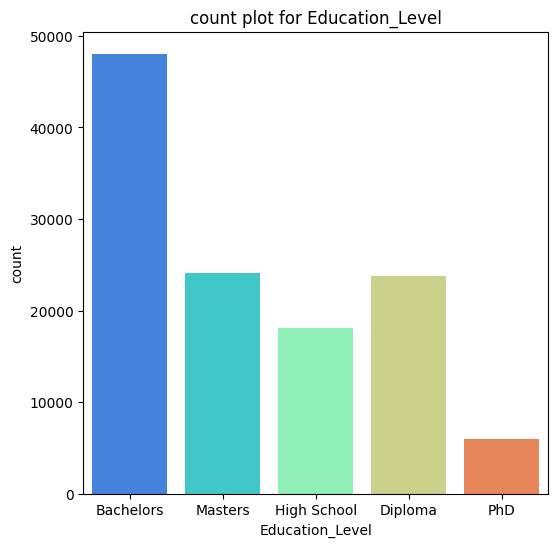

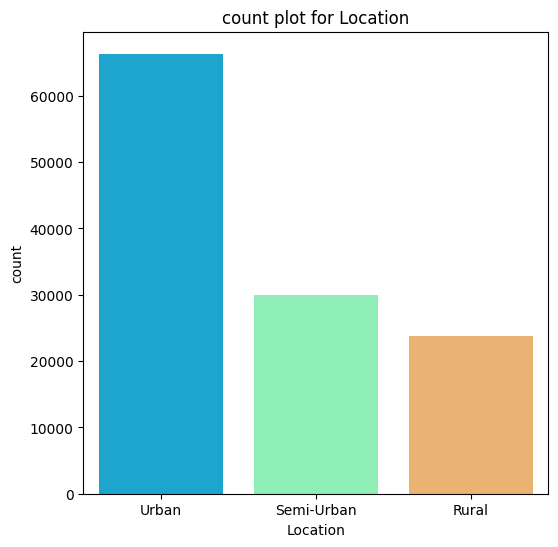

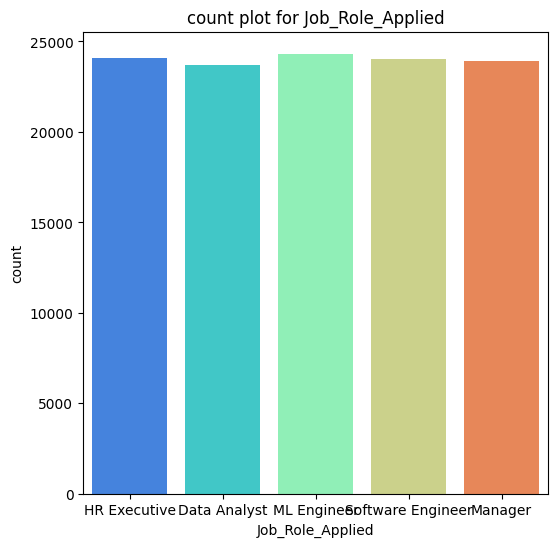

In [11]:
colmns=df.select_dtypes(include=['object']).columns.tolist()
for col in colmns[1:]:
    if df[col].nunique()<10:
        plt.figure(figsize=(6,6))
        sns.countplot(data=df,x=col,hue=col,palette='rainbow')
        plt.title(f"count plot for {col}")
        plt.show()

### Education_Level
- **Likely highest**: Bachelors and Masters, reflecting common applicant qualifications.  
- **Likely lowest**: PhD and Diploma, suggesting fewer applicants with these education levels.

### Location
- **Likely highest**: Urban areas, indicating job market concentration or availability of roles in cities.  
- **Likely moderate**: Semi-Urban.  
- **Likely lowest**: Rural.

### Job_Role_Applied
- **Likely high count roles**: Software Engineer, Data Analyst, and HR_Executive, reflecting current in-demand positions.  
- **Likely moderate to low count roles**: ML_Engineer and Manager, depending on dataset specifics.

### Overall Insight
The candidate pool is **predominantly urban, educated at the bachelor’s or master’s level, and applying for tech/analyst roles**, aligning with current hiring trends in many industries.

<Figure size 600x600 with 0 Axes>

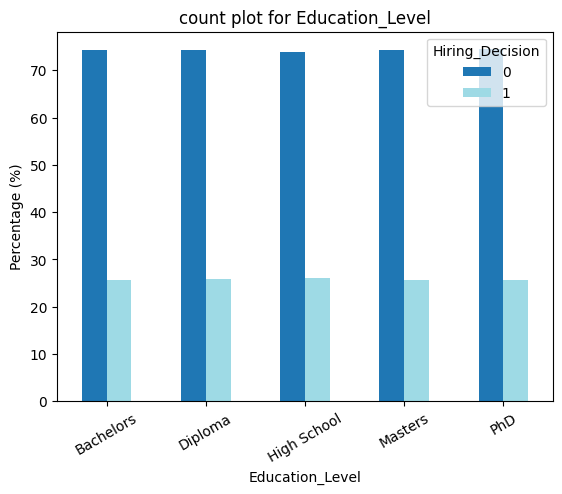

<Figure size 600x600 with 0 Axes>

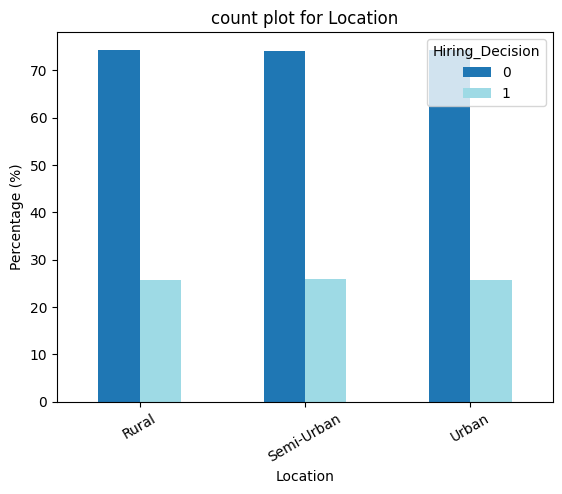

<Figure size 600x600 with 0 Axes>

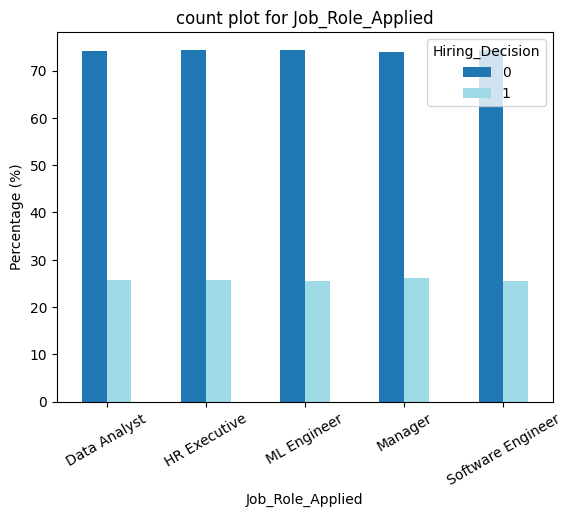

In [12]:
colmns=df.select_dtypes(include=['object']).columns.tolist()
for col in colmns[1:]:
    if df[col].nunique()<10:
        plt.figure(figsize=(6,6))
        # sns.countplot(data=df,x=col,hue='Hiring_Decision',palette='rainbow',)
        a=df.groupby([col, 'Hiring_Decision']).size().unstack().apply(lambda x: x/x.sum()*100,axis=1)
        a.plot(kind='bar',
               colormap='tab20')
        plt.xticks(rotation=30)
        plt.ylabel('Percentage (%)')
        plt.title(f"count plot for {col}")
        plt.show()

- Overall, **rejections are much higher than selections** across all categories.
- The dataset shows a **highly competitive hiring process**.
- Only a **small percentage of applicants are selected**.
- This trend is consistent across **education levels, locations, and job roles**.
- Indicates a **strict or selective recruitment system**.
- For every job role, more candidates are rejected than hired

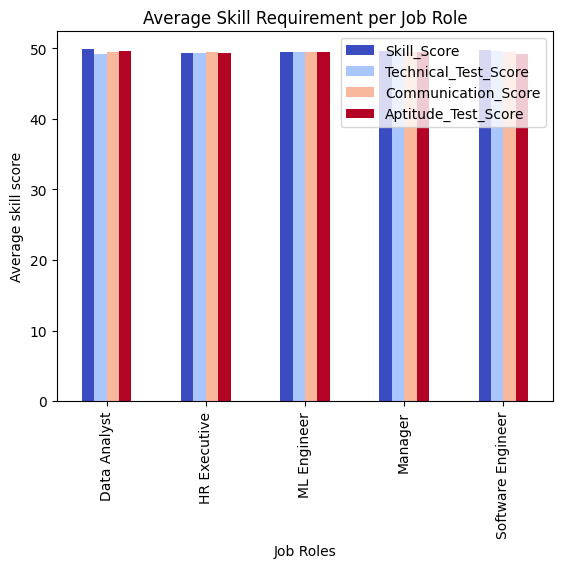

In [13]:
skills = ['Skill_Score', 'Technical_Test_Score', 'Communication_Score', 'Aptitude_Test_Score']

job_skill_avg = df.groupby('Job_Role_Applied')[skills].mean()
job_skill_avg.plot(kind='bar',colormap='coolwarm')
plt.title("Average Skill Requirement per Job Role")
plt.xlabel('Job Roles')
plt.ylabel('Average skill score')
plt.show()


 * All job roles require strong and balanced abilities.

 * Every role has similar expectations, rather than focusing on one skill.

In [14]:
df.columns

Index(['Candidate_ID', 'Gender', 'Age', 'Education_Level', 'Experience_Years',
       'Skill_Score', 'Aptitude_Test_Score', 'Technical_Test_Score',
       'Communication_Score', 'Certifications_Count', 'Previous_Companies',
       'Interview_Score', 'Location', 'Job_Role_Applied', 'Expected_Salary',
       'Hiring_Decision'],
      dtype='object')

Text(0.5, 1.0, 'Average Interview Score by Hiring Decision')

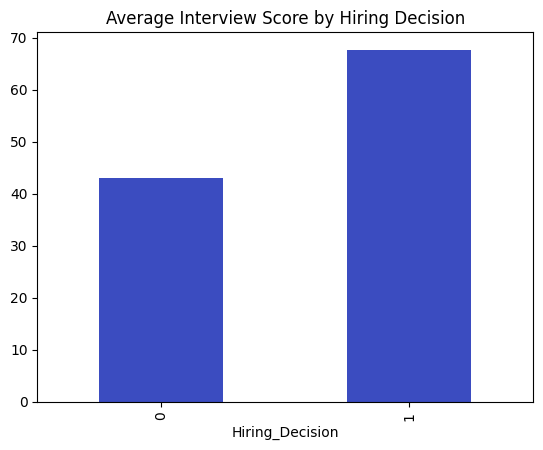

In [15]:
a= df.groupby('Hiring_Decision')['Interview_Score'].mean()
a.plot(kind='bar',colormap='coolwarm')
plt.title("Average Interview Score by Hiring Decision")

* Candidates with higher interview scores are more likely to be hired.

 * Lower interview scores lead to more rejections.

## Feature creation

In [16]:
df['Experience_Level'] = pd.cut(
    df['Experience_Years'],
    bins=[-1, 2, 5, 10, 20],
    labels=['Fresher', 'Junior', 'Mid', 'Senior']
)

df['Experience_Level'] = df['Experience_Level'].map({
    'Fresher': 0,
    'Junior': 1,
    'Mid': 2,
    'Senior': 3
}).astype(int)


In [17]:
df['Total_Skill_Score'] = (
    df['Skill_Score'] +
    df['Aptitude_Test_Score'] +
    df['Technical_Test_Score'] +
    df['Communication_Score']
)

In [18]:
df['Experience_Ratio'] = df['Experience_Level'] / df['Age']
# Shows early vs late career progress


# High Experience_Ratio → Rapid growth (young but high level)

# Low Experience_Ratio → Slow growth (older but still junior/mid)

In [19]:
career_cap = np.percentile(df['Experience_Ratio'], 95)
print(career_cap)


0.12


In [20]:
def career_stage(ratio, cap=0.12):
    if ratio >= 0.9*cap:
        return 'Near Career Cap'
    elif ratio >= 0.5*cap:
        return 'Mid Growth'
    else:
        return 'Early Stage'

df['Career_Stage'] = df['Experience_Ratio'].apply(career_stage)


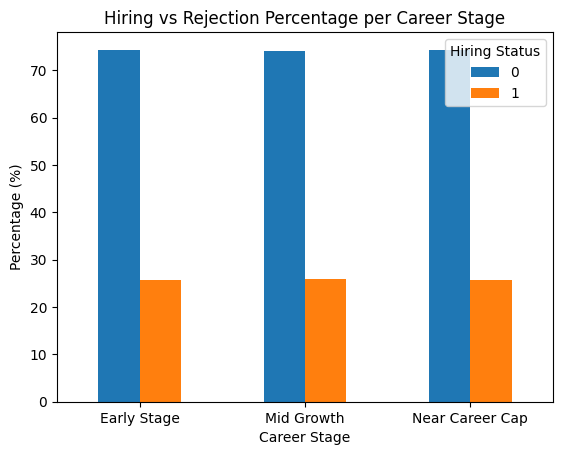

In [21]:
# Everything in one chain
df.groupby(['Career_Stage', 'Hiring_Decision']).size().unstack().apply(lambda x: x/x.sum()*100, axis=1).plot.bar()
plt.title('Hiring vs Rejection Percentage per Career Stage')
plt.xlabel('Career Stage')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Hiring Status')
plt.show()
plt.show()

In [22]:
df.drop(columns=['Experience_Years','Career_Stage','Experience_Ratio'],inplace=True)


### Reason for Dropping Career Stage
- All three career stages (**Early Stage**, **Mid Growth**, and **Near Career Cap**) showed **nearly identical hiring vs. rejection percentages**.
- There was **no meaningful variation** in hiring decisions based on career stage.
- Since the distribution was practically uniform, the feature does **not add predictive or explanatory value** to the model.
- Removing it helps reduce dimensionality and prevents noise without losing insight.

In [23]:
# stage_map = {
#     'Early Stage': 0,
#     'Mid Growth': 1,
#     'Near Career Cap': 2
# }

# # Encode Career_Stage into numbers
# df['Career_Stage'] = df['Career_Stage'].map(stage_map)

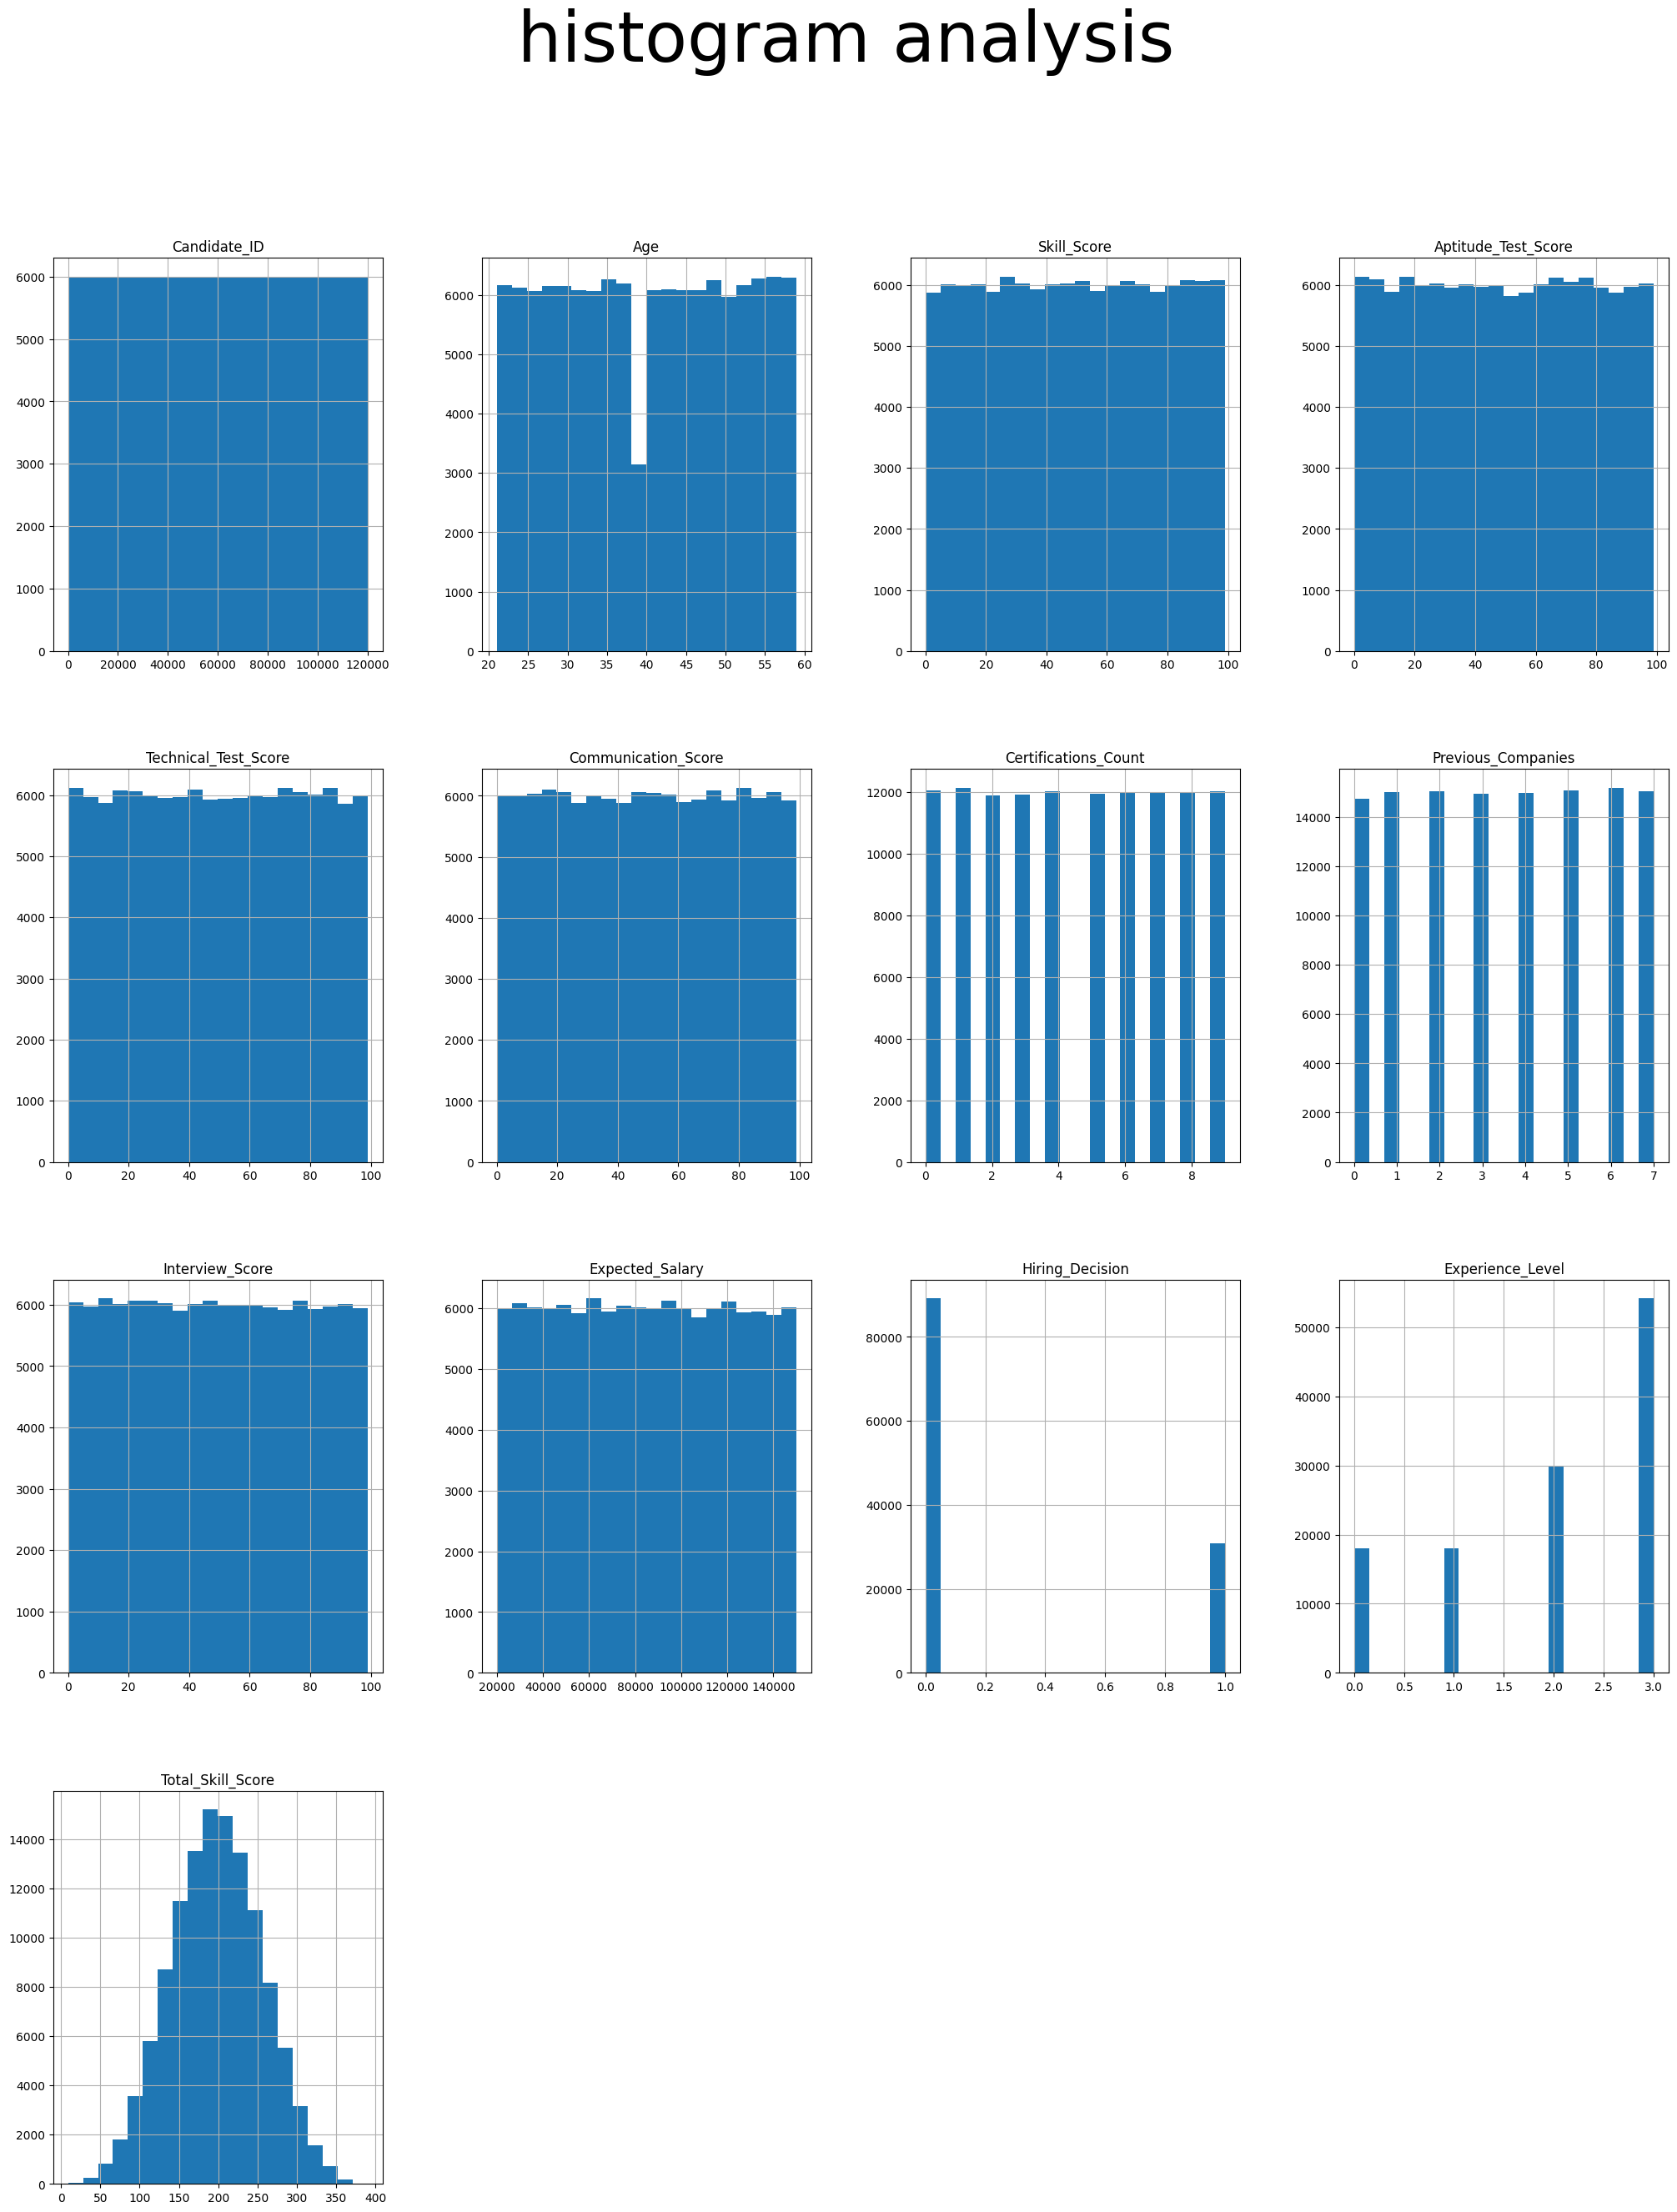

In [24]:
df.hist(bins=20,figsize=(25,30))
plt.suptitle(' histogram analysis',fontsize=60)
plt.show()

<Axes: >

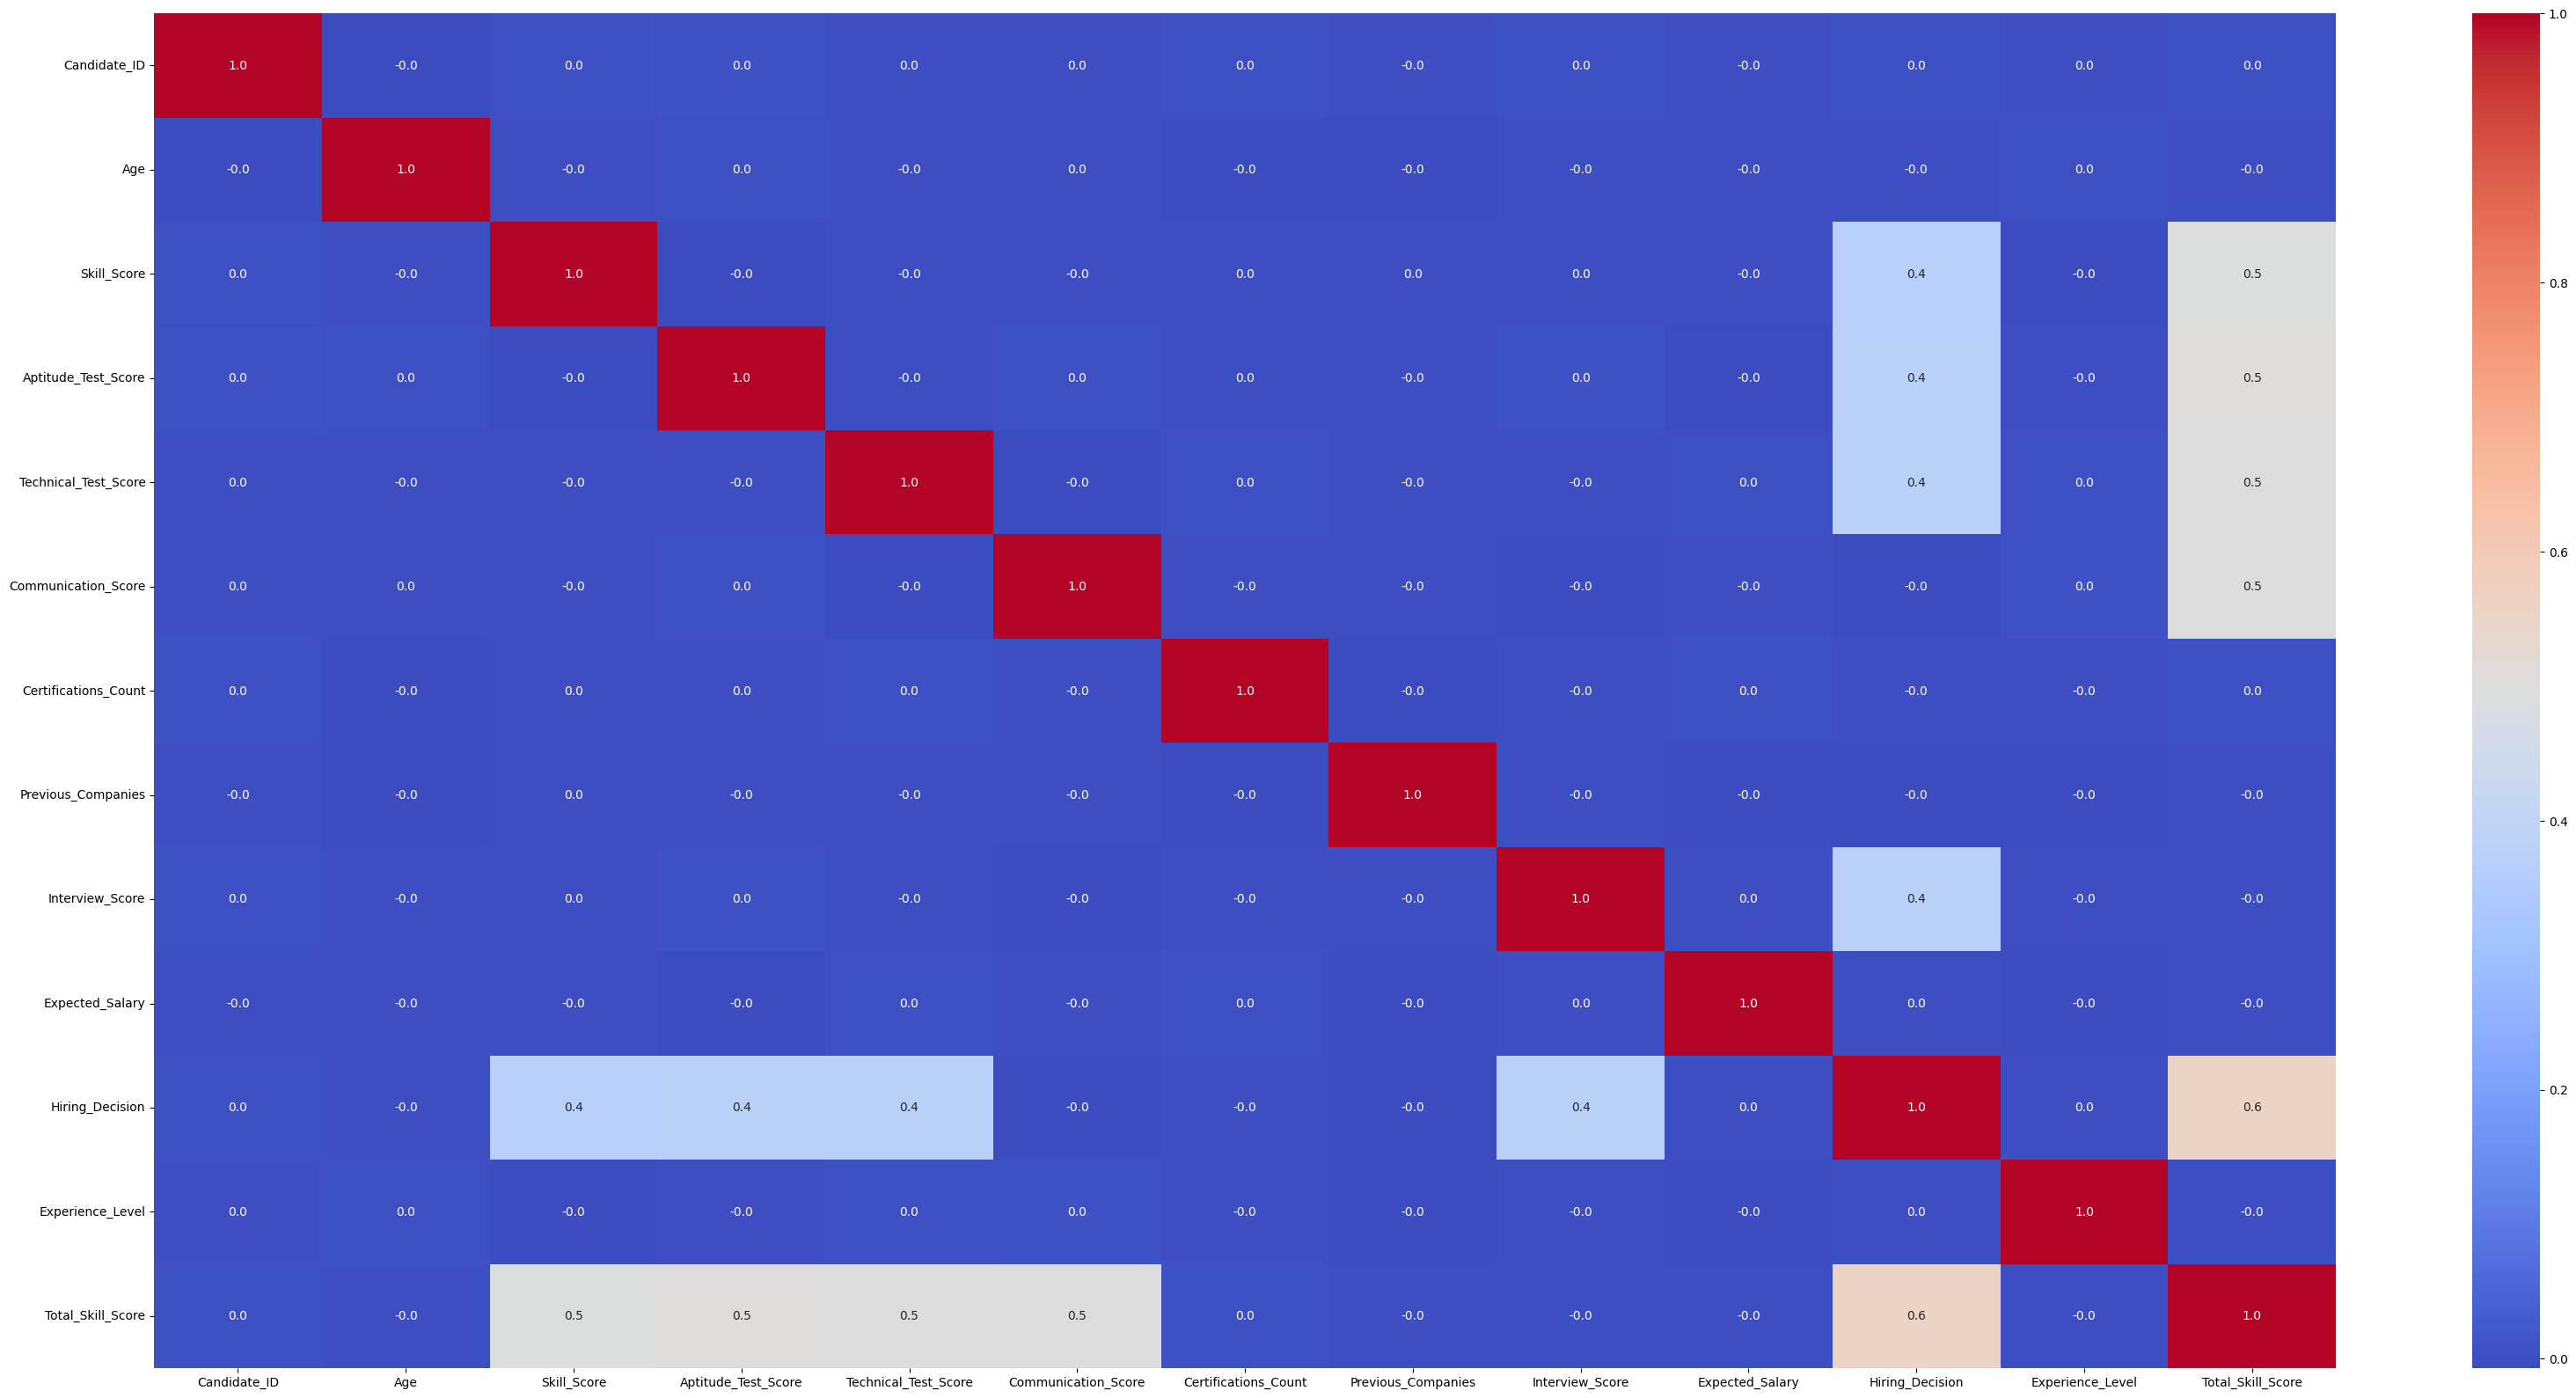

In [25]:
plt.figure(figsize=(40,20))
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='0.01f')

In [26]:
df.columns

Index(['Candidate_ID', 'Gender', 'Age', 'Education_Level', 'Skill_Score',
       'Aptitude_Test_Score', 'Technical_Test_Score', 'Communication_Score',
       'Certifications_Count', 'Previous_Companies', 'Interview_Score',
       'Location', 'Job_Role_Applied', 'Expected_Salary', 'Hiring_Decision',
       'Experience_Level', 'Total_Skill_Score'],
      dtype='object')

In [27]:
df.drop(columns=['Aptitude_Test_Score','Technical_Test_Score','Communication_Score','Skill_Score','Candidate_ID'],inplace=True)

In [28]:
column=df.select_dtypes(include=['int64','Int32'])

## find outliers

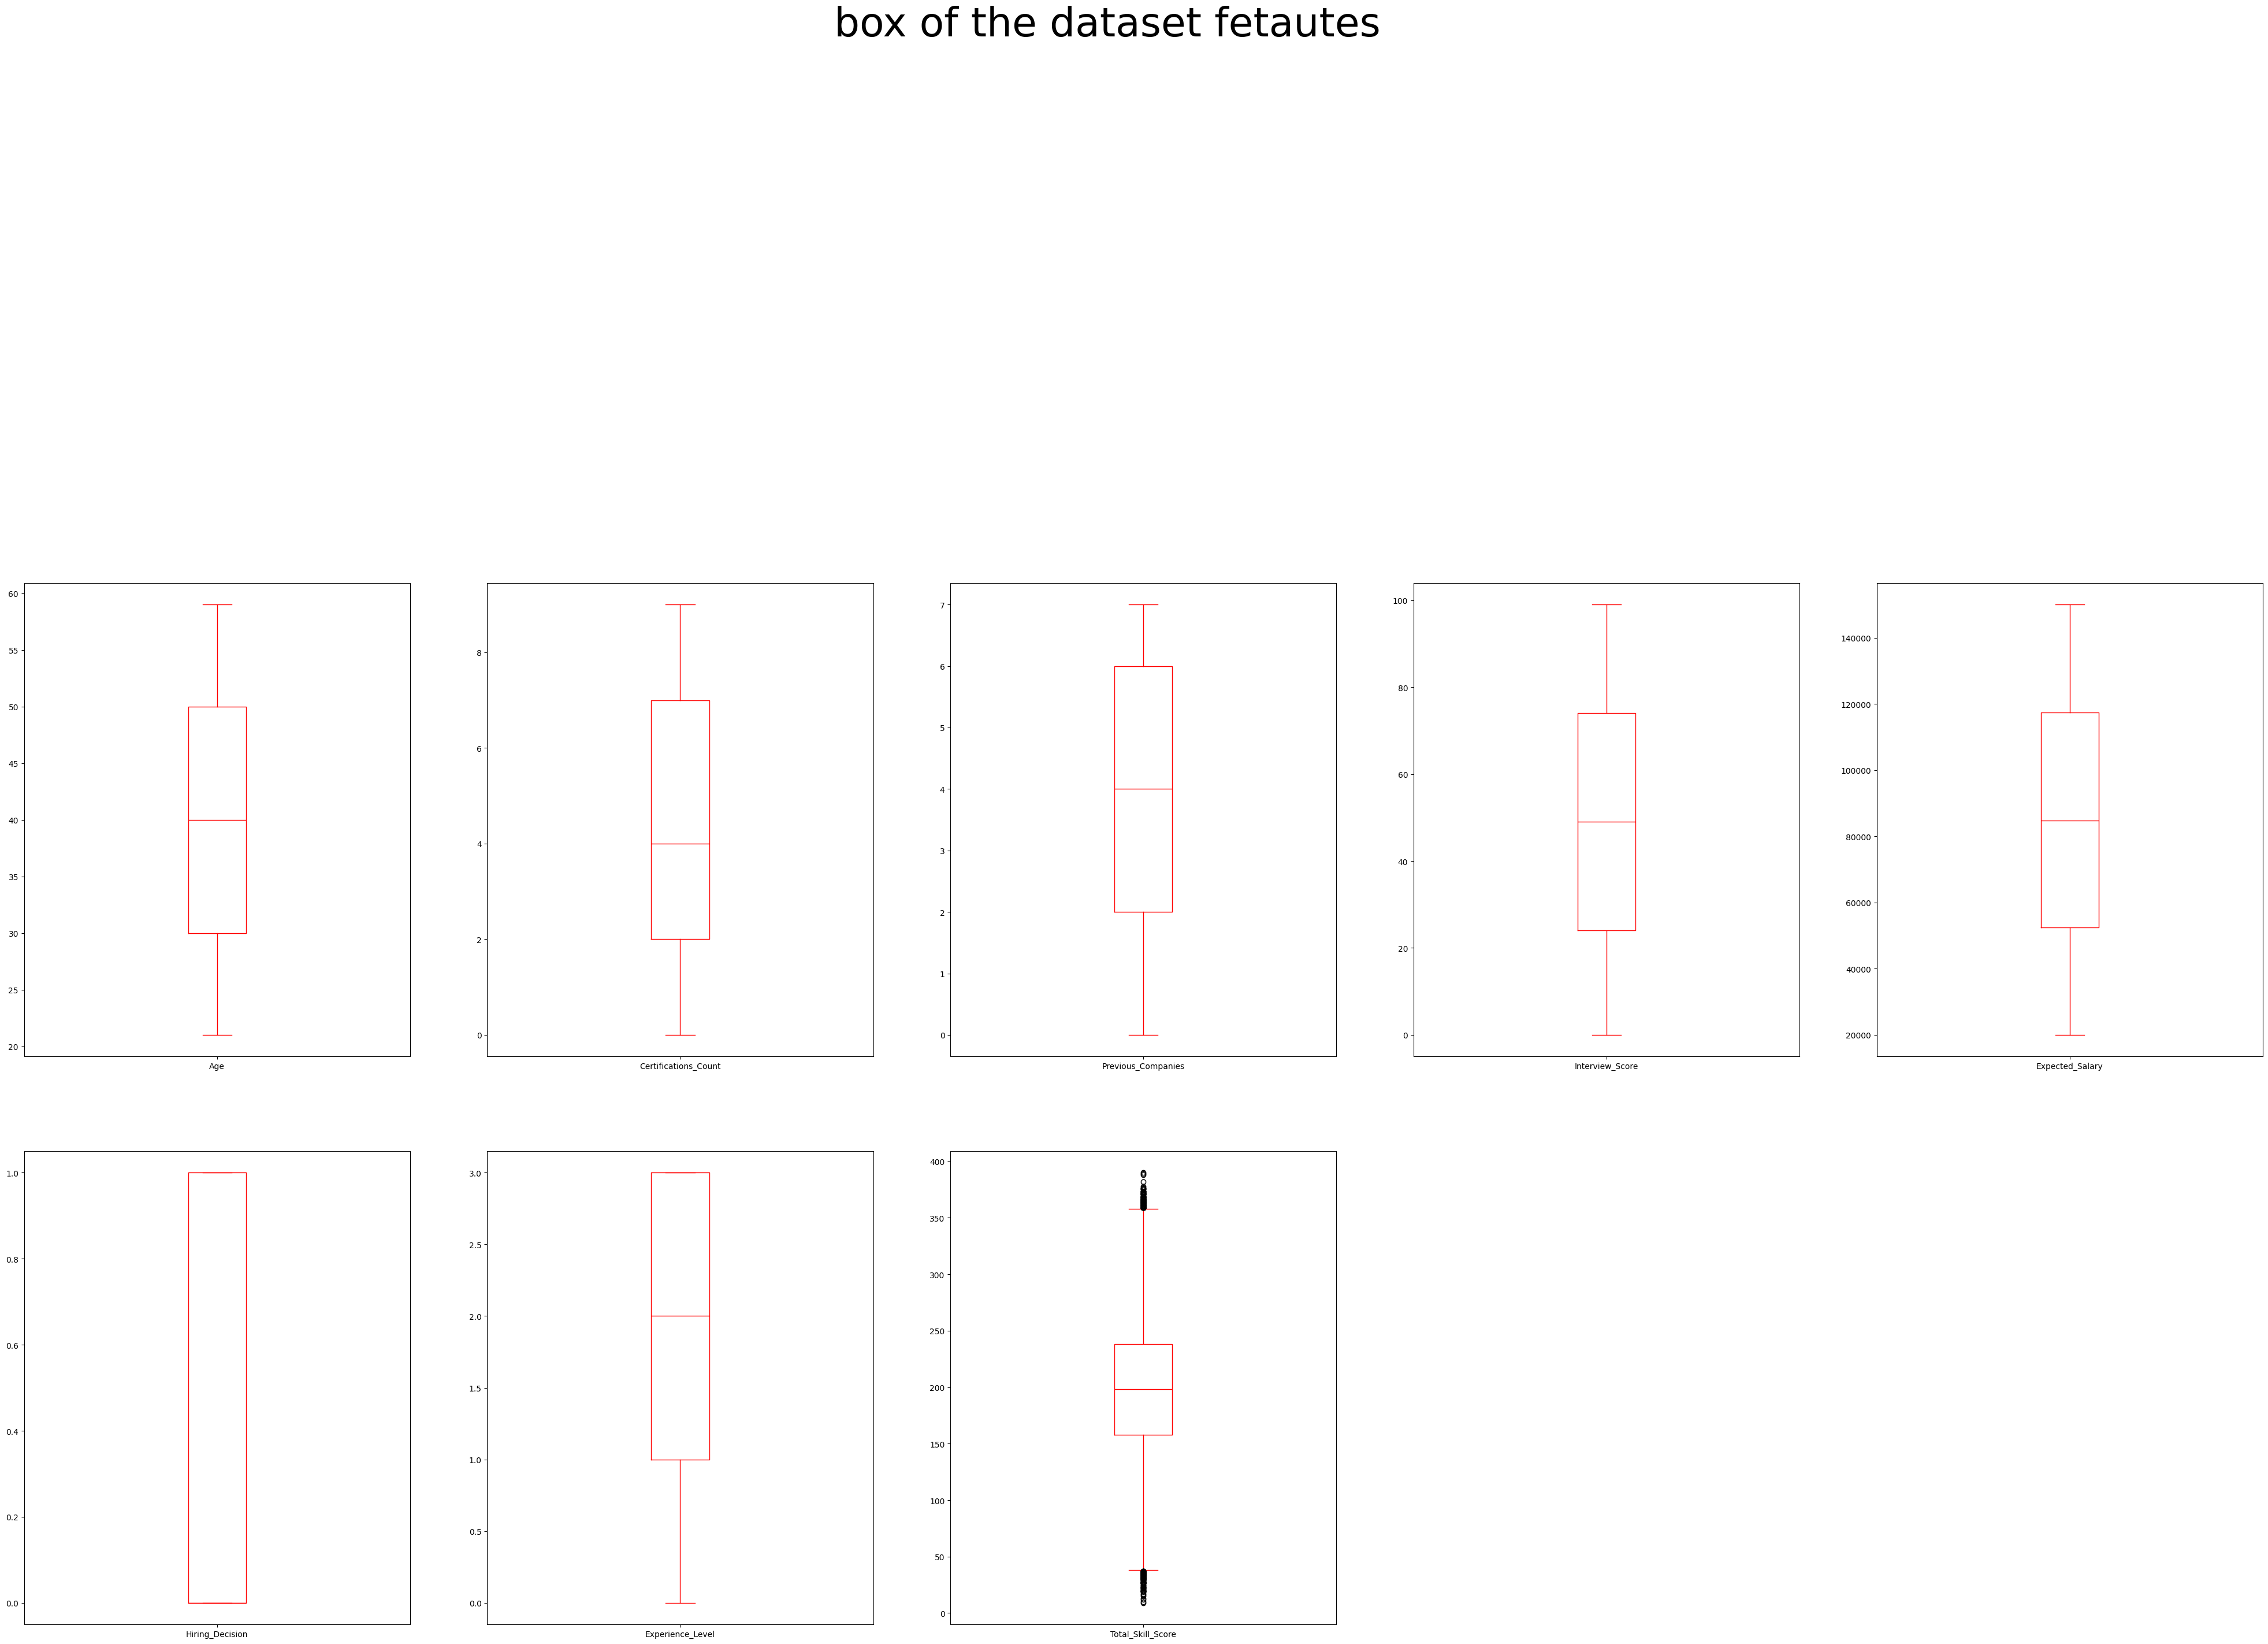

In [29]:
df.plot(kind='box',subplots=True,layout=(8,5),figsize=(50,100),color='r')
plt.suptitle('box of the dataset fetautes', fontsize=50)
plt.show()

### handel outlers

In [30]:
Q1 = df['Total_Skill_Score'].quantile(0.25)
Q3 = df['Total_Skill_Score'].quantile(0.75)
IQR = Q3 - Q1

# Outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Total_Skill_Score'] >= lower_bound) & (df['Total_Skill_Score'] <= upper_bound)]

## encoding
#### labelencoder

In [31]:
# Location
# Job_Role_Applied
# Education_Level
# Gender 
le=LabelEncoder()
df['Location']=le.fit_transform(df['Location'])
df['Job_Role_Applied']=le.fit_transform(df['Job_Role_Applied'])
df['Gender']=le.fit_transform(df['Gender'])




C:\Users\shmlp\AppData\Local\Temp\ipykernel_17224\519093344.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Location']=le.fit_transform(df['Location'])
C:\Users\shmlp\AppData\Local\Temp\ipykernel_17224\519093344.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Job_Role_Applied']=le.fit_transform(df['Job_Role_Applied'])
C:\Users\shmlp\AppData\Local\Temp\ipykernel_17224\519093344.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

### ordinal encoding

In [32]:
df['Education_Level'].unique()

array(['Bachelors', 'Masters', 'High School', 'Diploma', 'PhD'],
      dtype=object)

In [33]:
df['Education_Level']=df['Education_Level'].map({'High School': 0,
    'Diploma': 1,
    'Bachelors': 2,
    'Masters': 3,
    'PhD': 4})

C:\Users\shmlp\AppData\Local\Temp\ipykernel_17224\937411128.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Education_Level']=df['Education_Level'].map({'High School': 0,


In [34]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119771 entries, 0 to 120709
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                119771 non-null  int32  
 1   Age                   119771 non-null  int64  
 2   Education_Level       119771 non-null  int64  
 3   Certifications_Count  119771 non-null  float64
 4   Previous_Companies    119771 non-null  int64  
 5   Interview_Score       119771 non-null  int64  
 6   Location              119771 non-null  int32  
 7   Job_Role_Applied      119771 non-null  int32  
 8   Expected_Salary       119771 non-null  int64  
 9   Hiring_Decision       119771 non-null  int64  
 10  Experience_Level      119771 non-null  int32  
 11  Total_Skill_Score     119771 non-null  int64  
dtypes: float64(1), int32(4), int64(7)
memory usage: 10.1 MB


In [36]:
df['Hiring_Decision'].value_counts()

Hiring_Decision
0    88987
1    30784
Name: count, dtype: int64

### Split the Dataset

In [37]:
# -------------------------------
# 1. Split features and target
# -------------------------------
# Assuming 'Crop_Yield' is your target column
X = df.drop('Hiring_Decision', axis=1)
y = df['Hiring_Decision']

# -------------------------------
# 2. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,stratify=y, random_state=42
)

### Scale the Data

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Choose an Algorithm & Train the Model & Evaluate the Model

##### Need scaling model

In [39]:

models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'MLPClassifier': MLPClassifier(max_iter=500, random_state=42)
}

result = {'model': [], 'accuracy': [], 'precision': [], 'recall': [],'f1':[]}


for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    result['model'].append(name)
    result['accuracy'].append(accuracy_score(y_test, y_pred))
    result['precision'].append(precision_score(y_test, y_pred, average='weighted'))
    result['recall'].append(recall_score(y_test, y_pred, average='weighted'))
    result['f1'].append(f1_score(y_test, y_pred, average='weighted'))

In [40]:
result_df=pd.DataFrame(result)

result_df=result_df.sort_values(by='precision',ascending=True) 

result_df.style.background_gradient('Blues') 

,model,accuracy,precision,recall,f1
2,KNN,0.851555,0.846075,0.851555,0.846542
3,MLPClassifier,0.876226,0.872728,0.876226,0.872860
1,SVM,0.878689,0.875386,0.878689,0.874427
0,LogisticRegression,0.879357,0.876437,0.879357,0.877070


### no need scaling

In [41]:

models = {
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
    'DecisionTree_Classifier': DecisionTreeClassifier(random_state=42),
    'ExtraTreesClassifier': ExtraTreesClassifier(random_state=42),
    'AdaBoostClassifier': AdaBoostClassifier(random_state=42),
    'BaggingClassifier': BaggingClassifier(random_state=42),
    'LGBMClassifier': LGBMClassifier(random_state=42),
    'CatBoostClassifier': CatBoostClassifier(verbose=0, random_state=42)
    }

result1 = {'model': [], 'accuracy': [], 'precision': [], 'recall': [],'f1':[]}


for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    result1['model'].append(name)
    result1['accuracy'].append(accuracy_score(y_test, y_pred))
    result1['precision'].append(precision_score(y_test, y_pred, average='weighted'))
    result1['recall'].append(recall_score(y_test, y_pred, average='weighted'))
    result1['f1'].append(f1_score(y_test, y_pred, average='weighted'))

C:\Users\shmlp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shmlp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[LightGBM] [Info] Number of positive: 24627, number of negative: 71189
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 688
[LightGBM] [Info] Number of data points in the train set: 95816, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.257024 -> initscore=-1.061495
[LightGBM] [Info] Start training from score -1.061495


In [42]:
## no need scaling model evaluation
result_df=pd.DataFrame(result1)

result_df=result_df.sort_values(by='precision',ascending=True) 

result_df.style.background_gradient('Blues') 

,model,accuracy,precision,recall,f1
2,DecisionTree_Classifier,0.836068,0.836499,0.836068,0.836280
5,BaggingClassifier,0.862868,0.858251,0.862868,0.857564
4,AdaBoostClassifier,0.873429,0.870013,0.873429,0.867959
3,ExtraTreesClassifier,0.874306,0.870683,0.874306,0.869666
0,RandomForestClassifier,0.876143,0.872592,0.876143,0.872452
7,CatBoostClassifier,0.876143,0.872646,0.876143,0.872808
6,LGBMClassifier,0.879232,0.875904,0.879232,0.875832
1,GradientBoostingClassifier,0.879942,0.877329,0.879942,0.878056


In [ ]:
def perform_hypothesis_test(stat,p_value,
                            alpha=0.05,null_hypothesis="",
                            alternative_hypothesis=""):
    """ 
    perform hypothesis testing using a common decision rule for the p value 
    parameters:
    -stat :the test statistic.
    -p_value: the p value obtained from the test.
    -alpha : the significance level (default:0.05).
    -null_hypothesis:description of the null hypothesis
    alternative_hypothesis: description of the alternative hypothesis.
    returns:
    -dictionary containing results and decision"""
# decision rule: common for all tests
    decision=(f"reject the null hypothesis:{alternative_hypothesis}" 
          if p_value<alpha 
          else f"fail to reject the null hypothesis: {null_hypothesis}")
    return{'statistic':stat,
        'p_value':p_value,
        'alpha':alpha,
        "null_hypothesis":null_hypothesis,
        "alternative_hypothesis":alternative_hypothesis,
        "decision":decision,}



In [51]:
# from sklearn.model_selection import train_test_split
# from scipy.stats import ttest_rel
# # number of itreation for repeated evaluation
# n_iteration=20
# f1_logistic=[]
# f1_gradiante=[]
# # repeat model training and evaluation
# for i in range(n_iteration):
    
#     X_train,X_test_scaled_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=i)
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     log_model=LogisticRegression(max_iter=200,random_state=i)
#     log_model.fit(X_train_scaled,y_train)
#     y_pred_log=log_model.predict(X_test_scaled)
#     f1_logistic.append(f1_score(y_test,y_pred_log))

#     grad_model=GradientBoostingClassifier(random_state=i)
#     grad_model.fit(X_train,y_train)
#     y_pred_tree=grad_model.predict(X_test)
#     f1_gradiante.append(accuracy_score(y_test,y_pred_tree))

# t_stat,p_value=ttest_rel(f1_logistic,f1_gradiante)
# result_ttest=perform_hypothesis_test(stat=t_stat,p_value=p_value,alpha=0.05,
#                 null_hypothesis="The mean performance of Two models is equal",
#                 alternative_hypothesis="The mean performance of the two models is not equal")
# print('results :')
# result_ttest 



from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# number of iterations for repeated evaluation
n_iteration = 20
f1_logistic = []
f1_gradient = []

# repeat model training and evaluation
for i in range(n_iteration):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i)
    
    # Scale data for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Logistic Regression (needs scaling)
    log_model = LogisticRegression(max_iter=200, random_state=i)
    log_model.fit(X_train_scaled, y_train)
    y_pred_log = log_model.predict(X_test_scaled)
    f1_logistic.append(f1_score(y_test, y_pred_log))
    
    # Gradient Boosting (does NOT need scaling)
    grad_model = GradientBoostingClassifier(random_state=i)
    grad_model.fit(X_train, y_train)  # Use unscaled training data
    y_pred_grad = grad_model.predict(X_test)  # Use unscaled test data
    f1_gradient.append(f1_score(y_test, y_pred_grad))  # Use f1_score for consistency

t_stat, p_value = ttest_rel(f1_logistic, f1_gradient)

def perform_hypothesis_test(stat, p_value, alpha, null_hypothesis, alternative_hypothesis):
    result = {
        't_statistic': stat,
        'p_value': p_value,
        'alpha': alpha,
        'null_hypothesis': null_hypothesis,
        'alternative_hypothesis': alternative_hypothesis,
        'reject_null': p_value < alpha
    }
    return result

result_ttest = perform_hypothesis_test(
    stat=t_stat, 
    p_value=p_value, 
    alpha=0.05,
    null_hypothesis="The mean performance of two models is equal",
    alternative_hypothesis="The mean performance of the two models is not equal"
)

print('Results:')
print(result_ttest)

Results:
{'t_statistic': -10.011107789686209, 'p_value': 5.169727410868866e-09, 'alpha': 0.05, 'null_hypothesis': 'The mean performance of two models is equal', 'alternative_hypothesis': 'The mean performance of the two models is not equal', 'reject_null': True}


In [43]:
model=GradientBoostingClassifier(random_state=42)
model.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

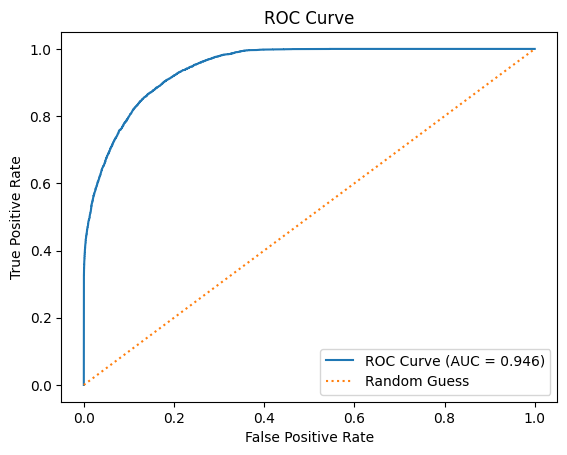

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities (IMPORTANT)
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle=':', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
# 

Excellent Model Performance: With an AUC score of 0.946, the model demonstrates a very strong ability to distinguish between positive and negative classes, performing significantly better than random guessing (AUC = 0.5).

In [45]:
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel
# number of itreation for repeated evaluation
n_iteration=20
acc_logistic=[]
acc_tree=[]
# repeat model training and evaluation
for i in range(n_iteration):
    # split the data randomly
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=i)
    # logistic Regreesion
    log_model=LogisticRegression(max_iter=200,random_state=i)
    log_model.fit(x_train,y_train)
    y_pred_log=log_model.predict(x_test)
    acc_logistic.append(accuracy_score(y_test,y_pred_log))
    # decision classifoer
    tree_model=GradientBoostingClassifier(random_state=i)
    tree_model.fit(x_train,y_train)
    y_pred_tree=tree_model.predict(x_test)
    acc_tree.append(accuracy_score(y_test,y_pred_tree))
# perform paired T test
t_stat,p_value=ttest_rel(acc_logistic,acc_tree)
result_ttest=perform_hypothesis_test(stat=t_stat,p_value=p_value,alpha=0.05,
                null_hypothesis="The mean performance of Two models is equal",
                alternative_hypothesis="The mean performance of the two models is not equal")
print('results :')
result_ttest 

NameError: name 'x' is not defined

                 feature  importance
10     Total_Skill_Score    0.681076
5        Interview_Score    0.315623
0                 Gender    0.002433
8        Expected_Salary    0.000478
3   Certifications_Count    0.000116
4     Previous_Companies    0.000085
1                    Age    0.000075
6               Location    0.000048
7       Job_Role_Applied    0.000031
2        Education_Level    0.000023


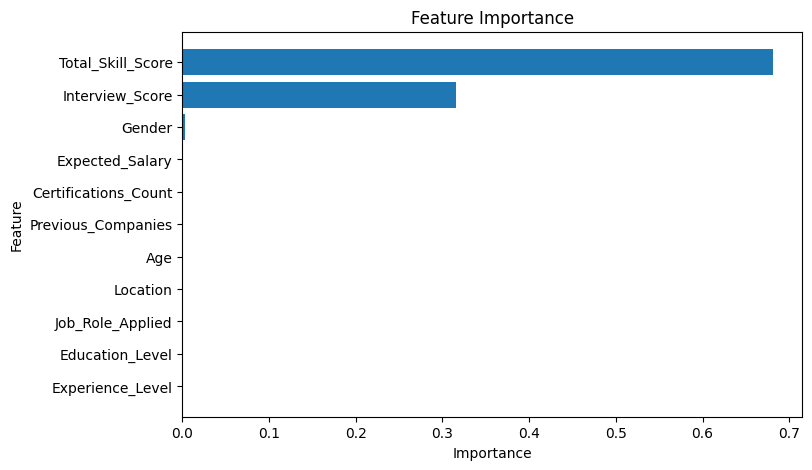

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Train model first

# Get feature importance
importance = model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

# Show top features
print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()


### Deploy the Model

In [ ]:
import pickle
model=LogisticRegression()
model.fit(X_train,y_train)
with open ('hiring.pkl','wb') as file:
    pickle.dump(model,file)
    

C:\Users\shmlp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# ✅ Final Project Report – Hiring Decision Prediction

## 📌 Project Objective  
The objective of this project is to build a machine learning model that predicts **hiring decisions** using key candidate attributes such as **Interview Score, Total Skill Score, and Education Level**. The system aims to support recruitment teams by identifying how different factors influence selection outcomes.

---

## 🤖 Final Model Selection  
After evaluating multiple machine learning models, the **Gradient Boosting Classifier** was selected as the final model due to its high accuracy, strong generalization ability, and minimal preprocessing requirements. As a tree-based model, it does not require feature scaling and effectively captures complex, non-linear relationships in the data.

---

## 🔍 Key Feature Relationships  

### 🗣 Interview Score vs Hiring Decision  
Interview Score is the **most influential factor** in hiring. Candidates scoring above **~80** have nearly a **90%+ probability of being hired**, while lower scores significantly increase rejection likelihood.

---

### 🧠 Total Skill Score Impact  
Total Skill Score strongly affects hiring outcomes. Candidates with higher and balanced skill scores are consistently preferred over those with weaker overall skill profiles.

---

### 🎓 Education Level Effect  
Education Level has a **moderate influence** on hiring. Candidates with Master’s and PhD degrees tend to perform better in hiring outcomes, but education alone cannot compensate for poor interview performance or low skill scores.

---

### 💼 Job Role vs Skill Requirement  
Analysis shows that **all job roles demand high performance across all skill categories**, rather than relying on one specific skill. Organizations prefer candidates with a **strong and well-balanced skill set**, regardless of the job role applied for.

---

## 📈 Overall Insight  
The model learns that:  
- **Interview Score is the primary driver of hiring decisions.**  
- **Total Skill Score provides strong supporting influence.**  
- **Education Level adds moderate value.**  
- **Every job role requires strong overall skills, not just a single specialized skill.**

---

## 🏁 Conclusion  
This project successfully meets its objective by building a reliable and interpretable hiring prediction system. By combining interview performance, skill competency, and educational background, the Gradient Boosting model provides accurate and practical decision support for recruitment processes.

---
